# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

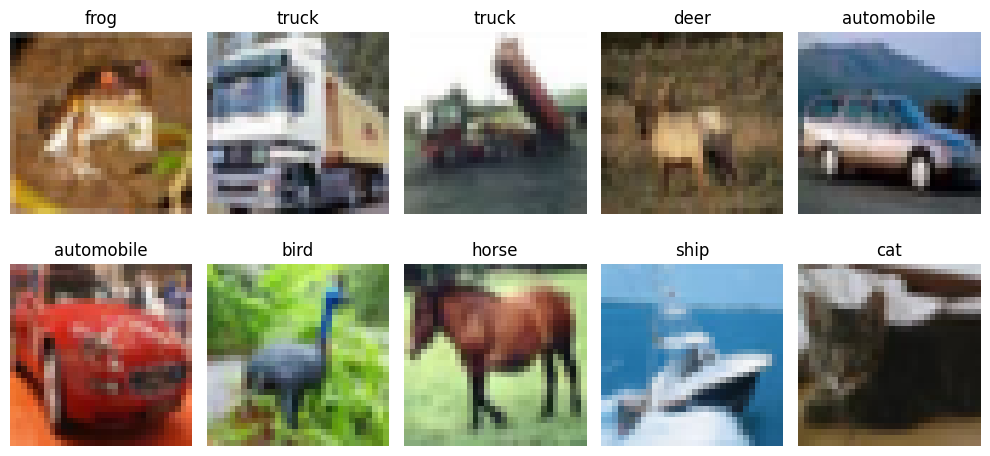

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.2639 - loss: 2.0017 - val_accuracy: 0.3328 - val_loss: 1.8386
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3103 - loss: 1.8765 - val_accuracy: 0.3512 - val_loss: 1.8260
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.3295 - loss: 1.8298 - val_accuracy: 0.3822 - val_loss: 1.7381
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3437 - loss: 1.7905 - val_accuracy: 0.3856 - val_loss: 1.7256
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3580 - loss: 1.7645 - val_accuracy: 0.3984 - val_loss: 1.7168
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3606 - loss: 1.7533 - val_accuracy: 0.3830 - val_loss: 1.7439
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3631 - loss: 1.7413 - val_accuracy: 0.4178 - val_loss: 1.6687
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3712 - loss: 1.7254 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4237 - loss: 1.6526
ANN Test Accuracy: 0.4237000048160553


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 129ms/step - accuracy: 0.4721 - loss: 1.4740 - val_accuracy: 0.5730 - val_loss: 1.2125
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.6081 - loss: 1.1177 - val_accuracy: 0.5514 - val_loss: 1.2689
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.6699 - loss: 0.9485 - val_accuracy: 0.6888 - val_loss: 0.9015
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7104 - loss: 0.8286 - val_accuracy: 0.6844 - val_loss: 0.9107
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 126ms/step - accuracy: 0.7472 - loss: 0.7294 - val_accuracy: 0.6124 - val_loss: 1.3952
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 129ms/step - accuracy: 0.7704 - loss: 0.6556 - val_accuracy: 0.6784 - val_loss: 0.9616
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.7968 - loss: 0.5815 - val_accuracy: 0.7296 - val_loss: 0.8259
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.8180 - loss:

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7167 - loss: 0.9227
CNN Test Accuracy: 0.71670001745224


## 📈 Compare Learning Curves

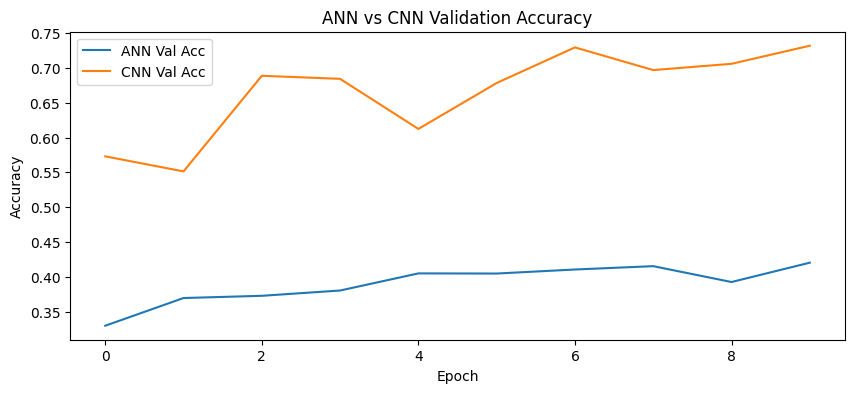

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4237
1,CNN,0.7167


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

In [1]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [2]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [3]:
print(X_train.shape)


(50000, 32, 32, 3)


# Task 1: Improved Artificial Neural Network (ANN)

This experiment increases the number of hidden layers to evaluate whether a deeper ANN can improve CIFAR-10 classification performance.

In [4]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

ann_deep = Sequential([
    Flatten(input_shape=(32,32,3)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

ann_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann_deep = ann_deep.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

ann_loss, ann_acc = ann_deep.evaluate(X_test, y_test)

print(f"Improved ANN Accuracy: {ann_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.3284 - loss: 1.8575 - val_accuracy: 0.3678 - val_loss: 1.7127
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.3994 - loss: 1.6721 - val_accuracy: 0.4183 - val_loss: 1.6389
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.4289 - loss: 1.5915 - val_accuracy: 0.4304 - val_loss: 1.5958
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.4474 - loss: 1.5430 - val_accuracy: 0.4524 - val_loss: 1.5289
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.4630 - loss: 1.5027 - val_accuracy: 0.4521 - val_loss: 1.5475
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.4701 - loss: 1.4770 - val_accuracy: 0.4660 - val_loss: 1.4901
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.4794 - loss: 1.4499 - val_accuracy: 0.4499 - val_loss: 1.5352
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.4868 -

# Task 2: Improved CNN with More Filters

This experiment increases convolutional filters from the original architecture to evaluate feature extraction performance.

In [5]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn_improved = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

cnn_improved.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn_improved = cnn_improved.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

cnn_loss, cnn_acc = cnn_improved.evaluate(X_test, y_test)

print(f"Improved CNN Accuracy: {cnn_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 170s 108ms/step - accuracy: 0.4858 - loss: 1.4327 - val_accuracy: 0.5931 - val_loss: 1.1512
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 164s 105ms/step - accuracy: 0.6313 - loss: 1.0528 - val_accuracy: 0.6456 - val_loss: 1.0066
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 166s 106ms/step - accuracy: 0.6886 - loss: 0.8932 - val_accuracy: 0.6847 - val_loss: 0.9051
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 171s 109ms/step - accuracy: 0.7253 - loss: 0.7848 - val_accuracy: 0.6961 - val_loss: 0.8807
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 167s 107ms/step - accuracy: 0.7538 - loss: 0.7003 - val_accuracy: 0.7119 - val_loss: 0.8593
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 164s 105ms/step - accuracy: 0.7805 - loss: 0.6208 - val_accuracy: 0.7015 - val_loss: 0.8984
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 165s 105ms/step - accuracy: 0.8052 - loss: 0.5528 - val_accuracy: 0.6877 - val_loss: 0.9649
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 201s 105ms/step - ac

# Task 3: CNN with 20 Epochs

This experiment trains the CNN for more epochs to observe learning behavior and possible overfitting.

In [6]:
history_cnn_20 = cnn_improved.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test)
)

cnn20_loss, cnn20_acc = cnn_improved.evaluate(X_test, y_test)

print(f"CNN Accuracy After 20 Epochs: {cnn20_acc:.4f}")

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 167s 107ms/step - accuracy: 0.8853 - loss: 0.3242 - val_accuracy: 0.6956 - val_loss: 1.1407
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 199s 105ms/step - accuracy: 0.8992 - loss: 0.2793 - val_accuracy: 0.6969 - val_loss: 1.2152
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 206s 107ms/step - accuracy: 0.9113 - loss: 0.2447 - val_accuracy: 0.6889 - val_loss: 1.3460
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 167s 107ms/step - accuracy: 0.9256 - loss: 0.2084 - val_accuracy: 0.6967 - val_loss: 1.4296
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 165s 106ms/step - accuracy: 0.9344 - loss: 0.1842 - val_accuracy: 0.6858 - val_loss: 1.5514
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 163s 104ms/step - accuracy: 0.9408 - loss: 0.1664 - val_accuracy: 0.6872 - val_loss: 1.6346
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 167s 107ms/step - accuracy: 0.9471 - loss: 0.1491 - val_accuracy: 0.6928 - val_loss: 1.7971
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 173s 111ms/step - ac

# Task 4: CNN with Early Stopping

This experiment uses EarlyStopping to stop training automatically when validation performance stops improving.

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_early = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

cnn_early.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_early = cnn_early.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

early_loss, early_acc = cnn_early.evaluate(X_test, y_test)

print(f"EarlyStopping CNN Accuracy: {early_acc:.4f}")

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 169s 107ms/step - accuracy: 0.4957 - loss: 1.4040 - val_accuracy: 0.5855 - val_loss: 1.1592
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 166s 106ms/step - accuracy: 0.6378 - loss: 1.0331 - val_accuracy: 0.6355 - val_loss: 1.0407
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 166s 106ms/step - accuracy: 0.6896 - loss: 0.8879 - val_accuracy: 0.6830 - val_loss: 0.9208
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 169s 108ms/step - accuracy: 0.7272 - loss: 0.7834 - val_accuracy: 0.6809 - val_loss: 0.9353
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 197s 105ms/step - accuracy: 0.7550 - loss: 0.6976 - val_accuracy: 0.6986 - val_loss: 0.9019
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 192s 123ms/step - accuracy: 0.7824 - loss: 0.6214 - val_accuracy: 0.7125 - val_loss: 0.8703
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 194s 124ms/step - accuracy: 0.8081 - loss: 0.5454 - val_accuracy: 0.6953 - val_loss: 0.9442
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 207s 127ms/step - ac

# Task 5: CNN with Data Augmentation

This experiment applies image augmentation to improve model generalization.

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

cnn_aug = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

cnn_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_aug = cnn_aug.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test)
)

aug_loss, aug_acc = cnn_aug.evaluate(X_test, y_test)

print(f"Augmented CNN Accuracy: {aug_acc:.4f}")

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 203s 129ms/step - accuracy: 0.4398 - loss: 1.5446 - val_accuracy: 0.5414 - val_loss: 1.2781
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 196s 125ms/step - accuracy: 0.5547 - loss: 1.2512 - val_accuracy: 0.6227 - val_loss: 1.0864
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 125ms/step - accuracy: 0.5986 - loss: 1.1394 - val_accuracy: 0.6442 - val_loss: 1.0331
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 194s 124ms/step - accuracy: 0.6247 - loss: 1.0648 - val_accuracy: 0.6634 - val_loss: 0.9700
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 125ms/step - accuracy: 0.6419 - loss: 1.0191 - val_accuracy: 0.6718 - val_loss: 0.9443
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 197s 126ms/step - accuracy: 0.6576 - loss: 0.9791 - val_accuracy: 0.6875 - val_loss: 0.9168
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 193s 124ms/step - accuracy: 0.6703 - loss: 0.9438 - val_accuracy: 0.6897 - val_loss: 0.9045
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 203s 124ms/step - ac

# Results Comparison

Record the final accuracies obtained from each experiment.

In [9]:
import pandas as pd

results = pd.DataFrame({
    "Experiment": [
        "Original ANN",
        "Original CNN",
        "Improved ANN",
        "Improved CNN",
        "CNN 20 Epochs",
        "CNN EarlyStopping",
        "CNN Data Augmentation"
    ],
    "Accuracy": [
        "Fill",
        "Fill",
        ann_acc,
        cnn_acc,
        cnn20_acc,
        early_acc,
        aug_acc
    ]
})

results

,Experiment,Accuracy
0,Original ANN,Fill
1,Original CNN,Fill
2,Improved ANN,0.463
3,Improved CNN,0.6986
4,CNN 20 Epochs,0.6834
5,CNN EarlyStopping,0.7125
6,CNN Data Augmentation,0.7408


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

The CIFAR-10 experiments demonstrate that Convolutional Neural Networks outperform Artificial Neural Networks for image classification tasks. Increasing the depth of the ANN provided limited improvement because flattening images removes important spatial information. CNN-based architectures achieved significantly higher accuracy by learning hierarchical image features through convolutional layers. Training the CNN for additional epochs led to overfitting and a reduction in test accuracy. Applying EarlyStopping improved generalization by preventing unnecessary training once validation performance stopped improving. The highest accuracy of 74.08% was achieved using data augmentation, which increased the diversity of training samples and helped the model generalize better to unseen images.
